### Importing Packages


In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler

#### PHASE 1: Data Collection & Exploration

##### 1. Loading dataset and checking shape


In [104]:
student = pd.read_csv("../data/raw/student_data.csv", sep=',')
student.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [105]:
print(student.shape)

print(student.dtypes)


(395, 33)
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [106]:
print(student.info())

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [107]:
print(student.isna().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [108]:
### Target variable

student["pass_fail"] = (
    (student["G3"] >=10).astype(int)
)
student.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass_fail
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,1


C:\Users\paude\AppData\Local\Temp\ipykernel_11960\2980332776.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_xticklabels(['Fail (0)', 'Pass (1)'])


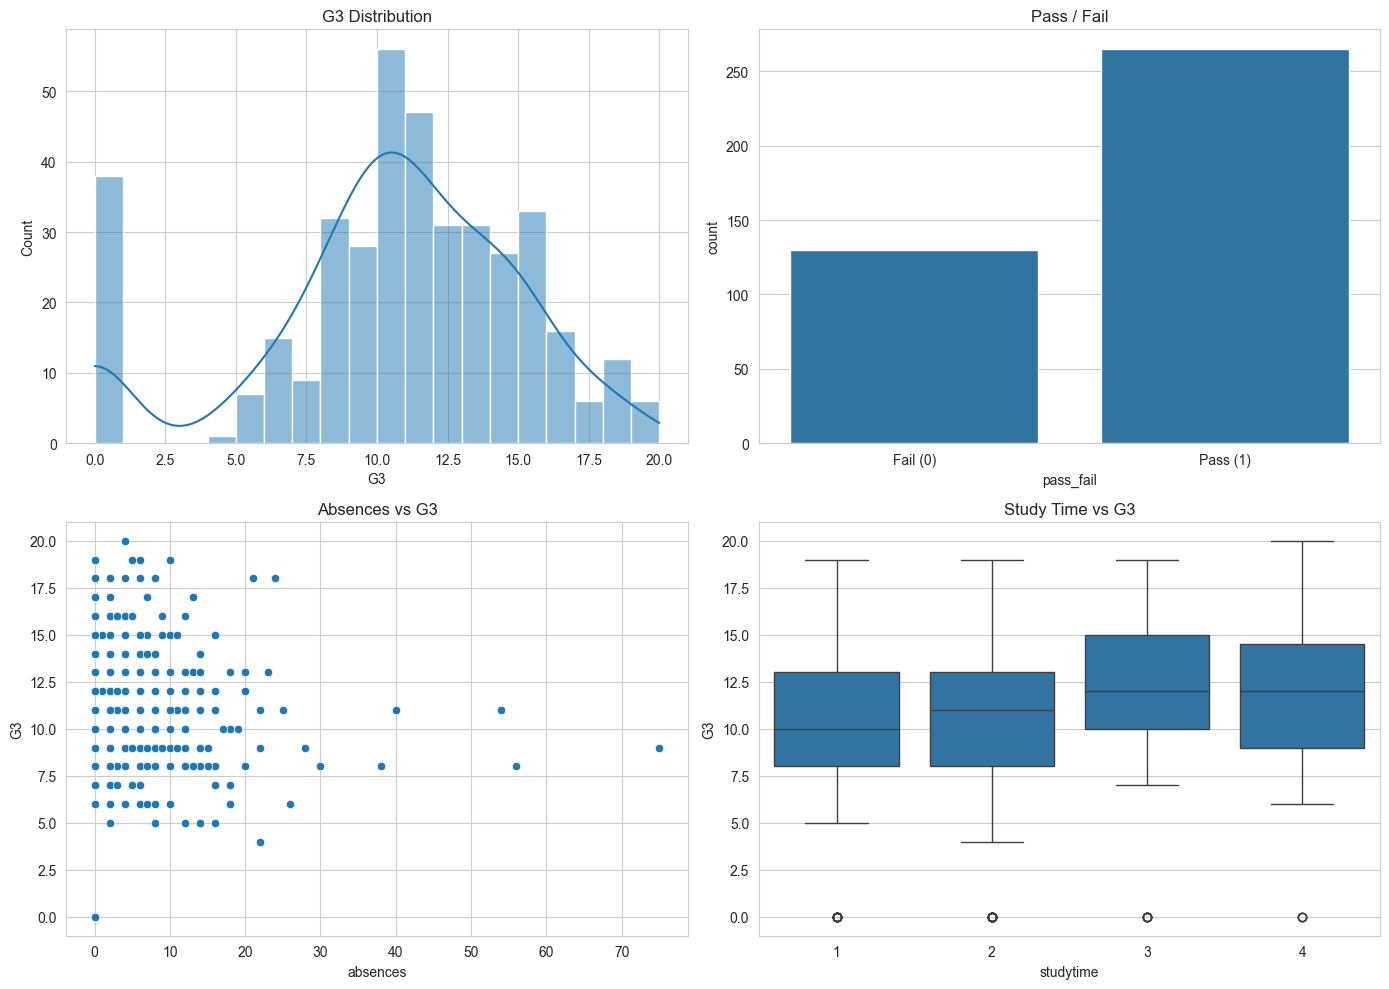

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. G3 Distribution
sns.histplot(student['G3'], bins=20, kde=True, ax=ax[0, 0])
ax[0, 0].set_title("G3 Distribution")

# 2. Pass / Fail Count
sns.countplot(x=student['pass_fail'], ax=ax[0, 1])
ax[0, 1].set_xticklabels(['Fail (0)', 'Pass (1)'])
ax[0, 1].set_title("Pass / Fail")

# 3. Absences vs G3
sns.scatterplot(x=student['absences'], y=student['G3'], ax=ax[1, 0])
ax[1, 0].set_title("Absences vs G3")

# 4. Study Time vs G3
sns.boxplot(x=student['studytime'], y=student['G3'], ax=ax[1, 1])
ax[1, 1].set_title("Study Time vs G3")

plt.tight_layout()
plt.savefig("../artifacts/images/student_data_analysis.png")
plt.show()

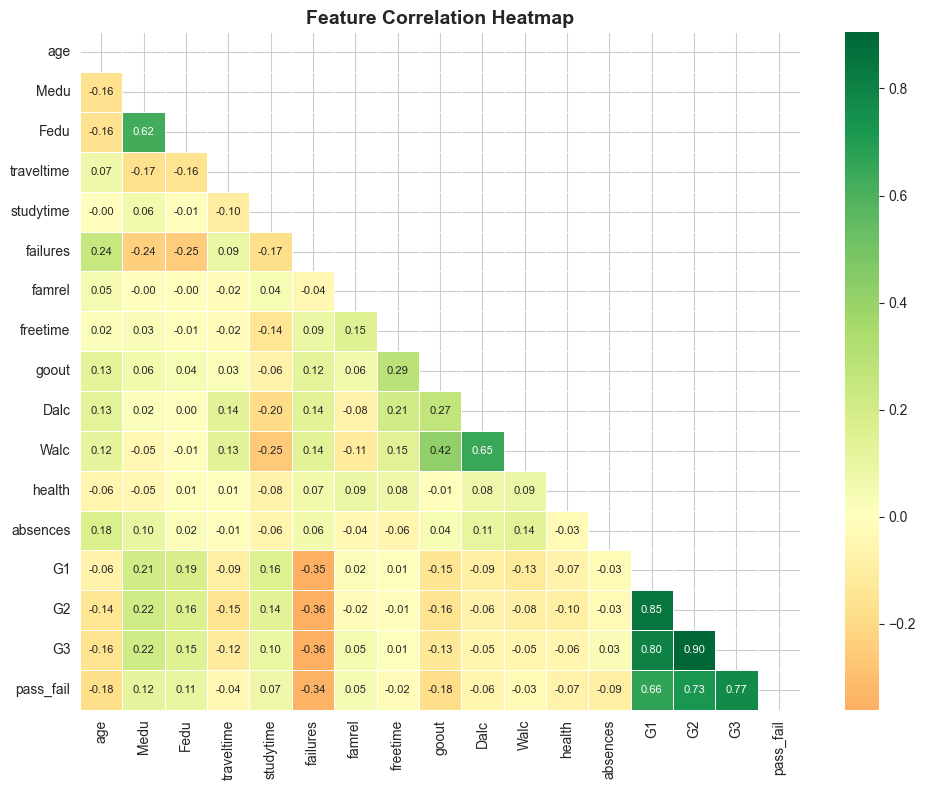

In [110]:
num_cols = student.select_dtypes(include=np.number).columns.tolist()
corr = student[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'E:\Student_Performance\artifacts\images\correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

#### Data Preprocessing

In [111]:
cat_col = student.select_dtypes(exclude= ["number", "int64"]).columns
num_col = student.select_dtypes(include= ["number", "int64"]).columns


In [112]:
cat_col

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

In [113]:
num_col

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'pass_fail'],
      dtype='str')

In [114]:
le = LabelEncoder()

for col in cat_col:
    student[col] = le.fit_transform(student[col]) 
    
weak_col = student.corr()['pass_fail'].abs().sort_values(ascending = False)

weak_cols = [c for c in weak_col[weak_col < 0.05].index if c != 'pass_fail']
print(f"Dropping {weak_cols}")

student.drop(columns=weak_cols, inplace=True)

X = student.drop(columns=["G3", "pass_fail"])
y = student["pass_fail"]

num_cols = X.select_dtypes(include= [np.number]).columns.tolist()
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
print(f"Feature shape in X: {X.shape}")


Dropping ['famrel', 'traveltime', 'Pstatus', 'famsize', 'school', 'Walc', 'Fjob', 'Mjob', 'freetime', 'activities', 'nursery']
Feature shape in X: (395, 21)


In [115]:
student.head()

,sex,age,address,Medu,Fedu,reason,guardian,studytime,failures,schoolsup,...,internet,romantic,goout,Dalc,health,absences,G1,G2,G3,pass_fail
0,0,18,1,4,4,0,1,2,0,1,...,0,0,4,1,3,6,5,6,6,0
1,0,17,1,1,1,0,0,2,0,0,...,1,0,3,1,3,4,5,5,6,0
2,0,15,1,1,1,2,1,2,3,1,...,1,0,2,2,3,10,7,8,10,1
3,0,15,1,4,2,1,1,3,0,0,...,1,1,2,1,5,2,15,14,15,1
4,0,16,1,3,3,1,0,2,0,0,...,0,0,2,1,5,4,6,10,10,1


In [116]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"Train: {X_train_sm.shape} | Test: {X_test.shape}")
print(f"After SMOTE: {np.bincount(y_train_sm)}")

Train: (424, 21) | Test: (79, 21)
After SMOTE: [212 212]


#### Train all 4 models


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score

In [118]:
models = {
    "LogisticRegression" : LogisticRegression(max_iter=1000, random_state=42),
    "RandomForestClassifier" : RandomForestClassifier(n_estimators=1000, random_state=42, class_weight="balanced"),
    "DecisionTreeClassifier" : DecisionTreeClassifier(random_state=42),
    "XGBoost" : XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0)
}

In [119]:
results ={}
con_mat ={}

for name, model in models.items():
    model.fit(X_train_sm,y_train_sm)
    y_pred =  model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5, scoring="f1").mean()
    cf = classification_report(y_test, y_pred, target_names=["Pass", "Fail"])
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'CV F1': cv}
    con_mat[name] = confusion_matrix(y_test, y_pred)
    print(f"\n{name}:")
    print(cf)
    
    
results_df = pd.DataFrame(results).T.round(4)
results_df


LogisticRegression:
              precision    recall  f1-score   support

        Pass       0.70      0.88      0.78        26
        Fail       0.93      0.81      0.87        53

    accuracy                           0.84        79
   macro avg       0.82      0.85      0.82        79
weighted avg       0.86      0.84      0.84        79


RandomForestClassifier:
              precision    recall  f1-score   support

        Pass       0.75      0.92      0.83        26
        Fail       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79


DecisionTreeClassifier:
              precision    recall  f1-score   support

        Pass       0.72      0.88      0.79        26
        Fail       0.94      0.83      0.88        53

    accuracy                           0.85        79
   macro avg       0.83      0.86      0.84        79
wei

,Accuracy,Precision,Recall,F1,CV F1
LogisticRegression,0.8354,0.9348,0.8113,0.8687,0.9329
RandomForestClassifier,0.8734,0.9574,0.8491,0.9000,0.9222
DecisionTreeClassifier,0.8481,0.9362,0.8302,0.8800,0.9174
XGBoost,0.8861,0.9583,0.8679,0.9109,0.9250


C:\Users\paude\AppData\Local\Temp\ipykernel_11960\3579325374.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df.index, rotation=20, ha='right', fontsize=9)


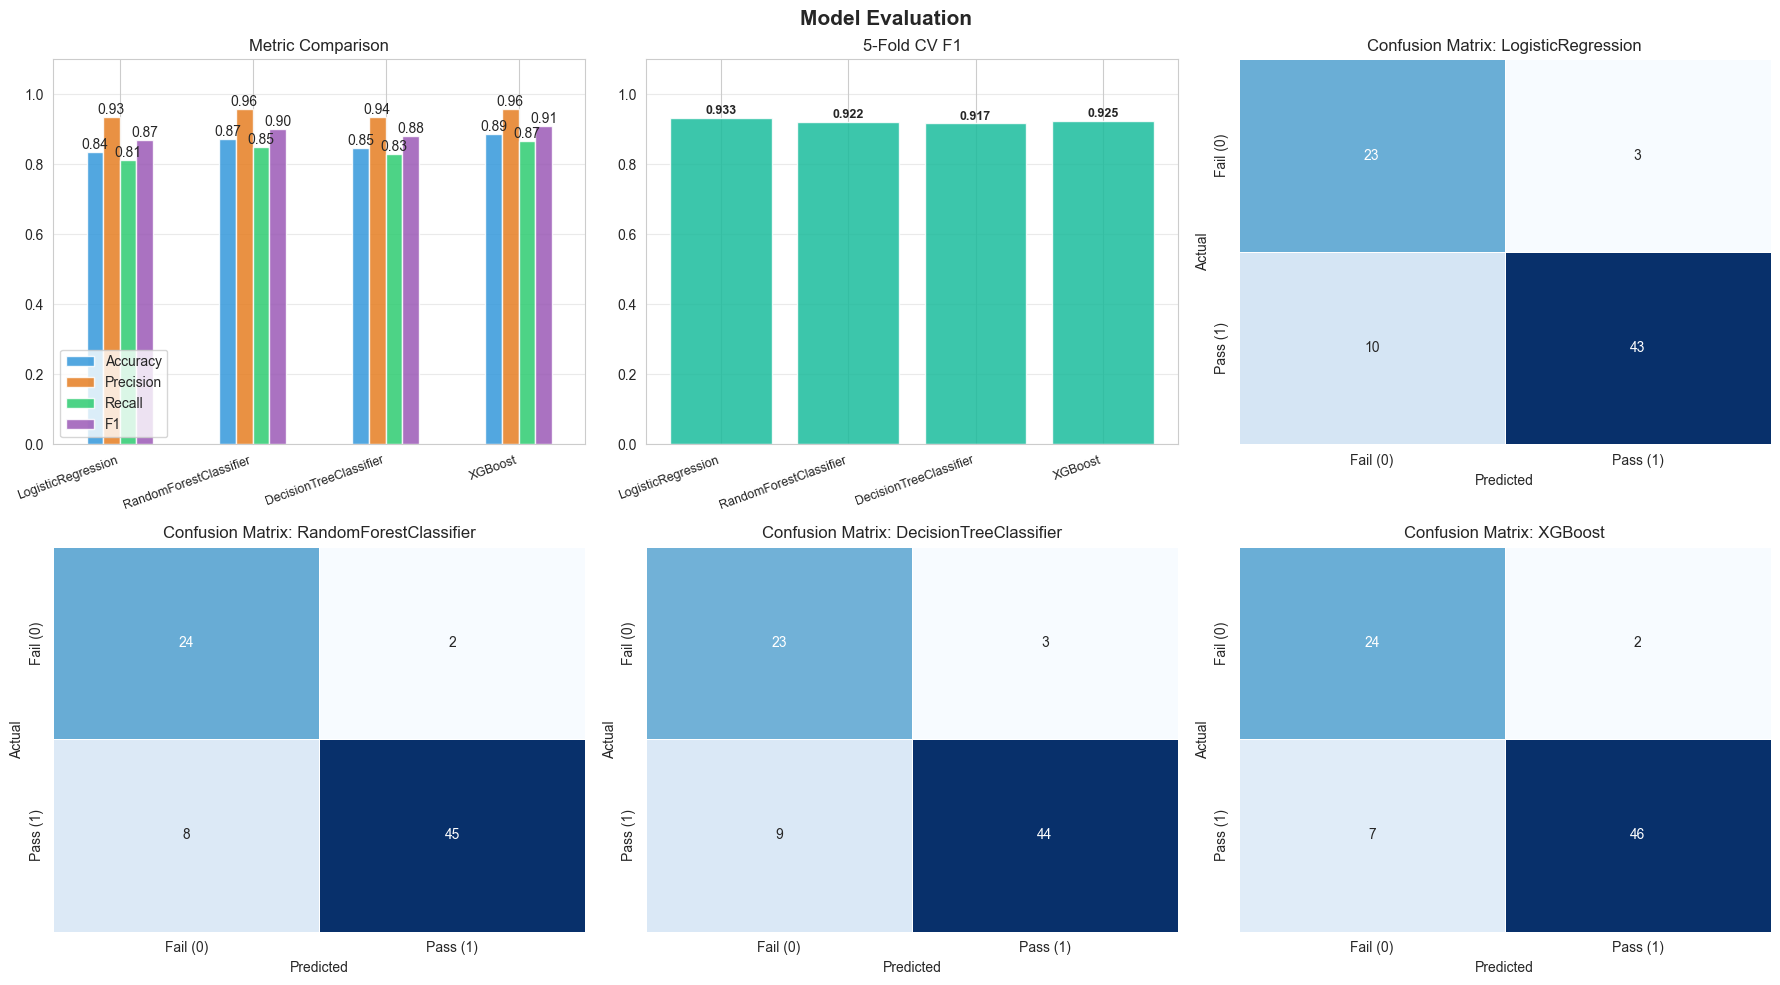

In [120]:
def plot_metrics(ax, df):
    df[['Accuracy','Precision','Recall','F1']].plot(
        kind='bar', ax=ax,
        color=['#3498db','#e67e22','#2ecc71','#9b59b6'],
        alpha=0.85, edgecolor='white')
    ax.set(title="Metric Comparison", ylim=(0,1.1))
    ax.set_xticklabels(df.index, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

def plot_cv(ax, df):
    ax.bar(df.index, df['CV F1'], color='#1abc9c', alpha=0.85, edgecolor='white')
    ax.set(title="5-Fold CV F1", ylim=(0,1.1))
    ax.set_xticklabels(df.index, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    for i, v in enumerate(df['CV F1']):
        ax.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

def plot_cms(axes, conf_matrices):
    for ax, (name, cm) in zip(axes, conf_matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Fail (0)','Pass (1)'], yticklabels=['Fail (0)','Pass (1)'],
                    cbar=False, linewidths=0.5)
        ax.set(title=f"Confusion Matrix: {name}", xlabel="Predicted", ylabel="Actual")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Evaluation", fontsize=15, fontweight='bold')

plot_metrics(axes[0,0], results_df)
plot_cv(axes[0,1], results_df)
plot_cms([axes[0,2], axes[1,0], axes[1,1], axes[1,2]], con_mat)

plt.tight_layout()
plt.savefig(r'E:\Student_Performance\artifacts\images\model_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

#### Hyperparamter tuning

In [121]:
from sklearn.model_selection import GridSearchCV

best_name = results_df['F1'].idxmax()
print(f"Best model: {best_name}")

param_grids = {
    'Random Forest':       {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'XGBoost':             {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]},
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    'Decision Tree':       {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]}
}

Best model: XGBoost


In [122]:
grid = GridSearchCV(models[best_name], param_grids[best_name], cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_sm, y_train_sm)
print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

tuned_model = grid.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Test F1      : {f1_score(y_test, y_pred_tuned):.4f}")

Best params : {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100}
Best CV F1  : 0.9266
Test Accuracy: 0.8861
Test F1      : 0.9109


#### Save the best model


In [123]:
import joblib
import os

os.makedirs(r"E:\Student_Performance\artifacts\models", exist_ok= True)
joblib.dump(tuned_model, r"E:\Student_Performance\artifacts\models\best_model.pkl")

print("Model has been saved to ---> E:\Student_Performance\artifacts\models\best_model.pkl")

Model has been saved to ---> E:\Student_Performancertifacts\modelest_model.pkl


<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\paude\AppData\Local\Temp\ipykernel_11960\2940214180.py:7: SyntaxWarning: invalid escape sequence '\S'
  print("Model has been saved to ---> E:\Student_Performance\artifacts\models\best_model.pkl")


In [124]:
data = joblib.load(r"E:\Student_Performance\artifacts\models\best_model.pkl")
print(f"Loading best model. Type: {type(data).__name__}")

Loading best model. Type: XGBClassifier
